### ***We will learn about Standard Scaling On Social Advertising Ads data***

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [2]:
# Import the data
raw_df = pd.read_csv("Social_Network_Ads.csv")

#------- Peek into the DataFrame-----------

print(raw_df.head())

print(f"\nDataSet Info \n{raw_df.info()}")
print(f"Shape of the Data -> {raw_df.shape}")

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB

DataSet Info 
None
Shape of the Data -> (400, 5)


In [3]:
# Removing the unnecessary columns (we will remove Gender Column for now since we Do not know NominalEncoding rn)
X = raw_df[['Age','EstimatedSalary']]
y = raw_df.iloc[:,-1]

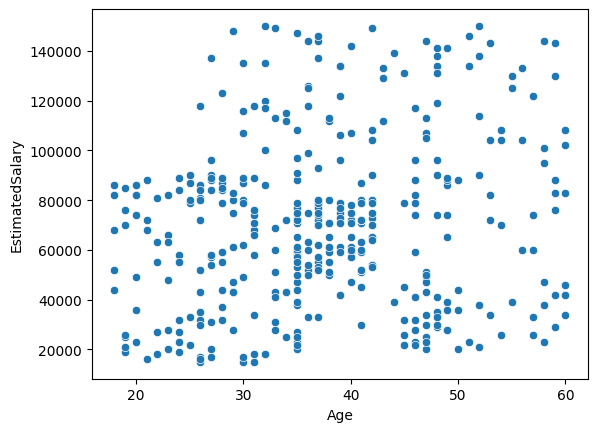

In [7]:
# Let us plot the Data of Age vs Salary
import seaborn as sns
sns.scatterplot(data = X , x = X['Age'] , y = X['EstimatedSalary'])
plt.show()

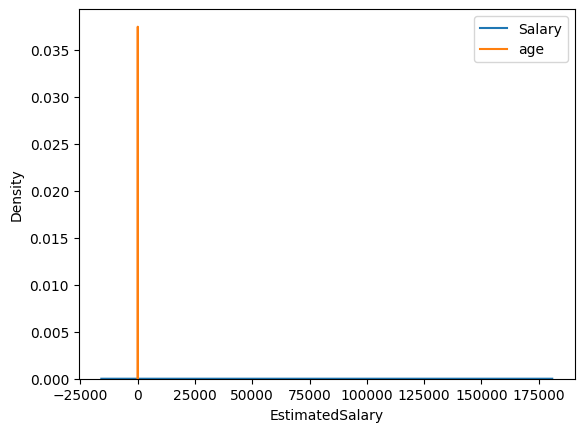

In [13]:
# Looking at the kdeplot of each column
sns.kdeplot(data=X , x = 'EstimatedSalary' , label='Salary')
sns.kdeplot(data=X , x='Age' , label = "age")
plt.legend()
plt.show()

In [20]:
# Let us train test split it 
X_train , X_test, y_train,y_test = train_test_split(X,y , test_size=.3 , random_state=42)

print(f"X_train -> {X_train.shape}")
print(f"X_test -> {X_test.shape}")
print(f"y_train -> {y_train.shape}")
print(f"y_test -> {y_test.shape}")

X_train -> (280, 2)
X_test -> (120, 2)
y_train -> (280,)
y_test -> (120,)


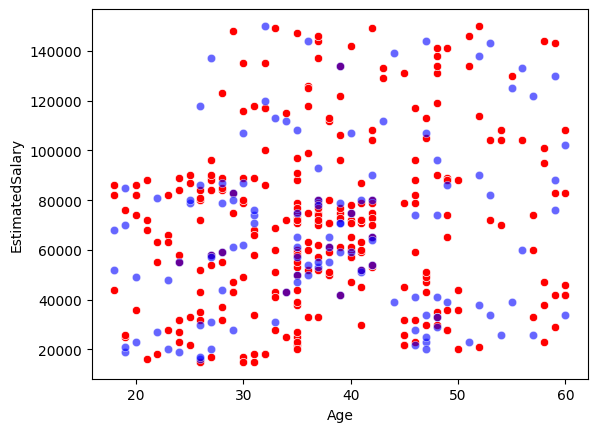

In [21]:
# Let us plot the Training and Testing Data of Age vs Salary
import seaborn as sns
sns.scatterplot(data = X_train , x = "Age" , y = "EstimatedSalary" , color = 'red')
sns.scatterplot(data = X_test , x = "Age" , y = "EstimatedSalary" , color = 'blue' , alpha=.6)
plt.show()

In [22]:
# Now Let us Firstly Fit the Logistic Regression Model Without Scaling the features and look at the evaluation
lr = LogisticRegression()
model = lr.fit(X_train , y_train)
y_pred = model.predict(X_test)


#--------------- Evaluation -----------------

print(f"Without Scaled\nAccuracy Score -> {accuracy_score(y_test , y_pred)}")



Without Scaled
Accuracy Score -> 0.85


### ***Scaling the Columns***

In [23]:
scale = StandardScaler()

X_train_scaled = pd.DataFrame(scale.fit_transform(X_train) , columns = X_train.columns)
X_test_scaled = pd.DataFrame(scale.transform(X_test) , columns = X_test.columns)

print(X_train.describe())
print(f"\n{X_train_scaled.describe()}")

              Age  EstimatedSalary
count  280.000000       280.000000
mean    37.575000     70589.285714
std     10.196005     33948.504534
min     18.000000     15000.000000
25%     30.000000     44000.000000
50%     37.000000     71000.000000
75%     45.000000     88000.000000
max     60.000000    150000.000000

                Age  EstimatedSalary
count  2.800000e+02     2.800000e+02
mean  -2.727977e-16     1.205385e-16
std    1.001791e+00     1.001791e+00
min   -1.923307e+00    -1.640391e+00
25%   -7.442683e-01    -7.846264e-01
50%   -5.649561e-02     1.211982e-02
75%    7.295303e-01     5.137749e-01
max    2.203329e+00     2.343340e+00


**We can clearly see that after Scaling Our Overall Mean for both the columns became 0 and Standard Deviation became 1**

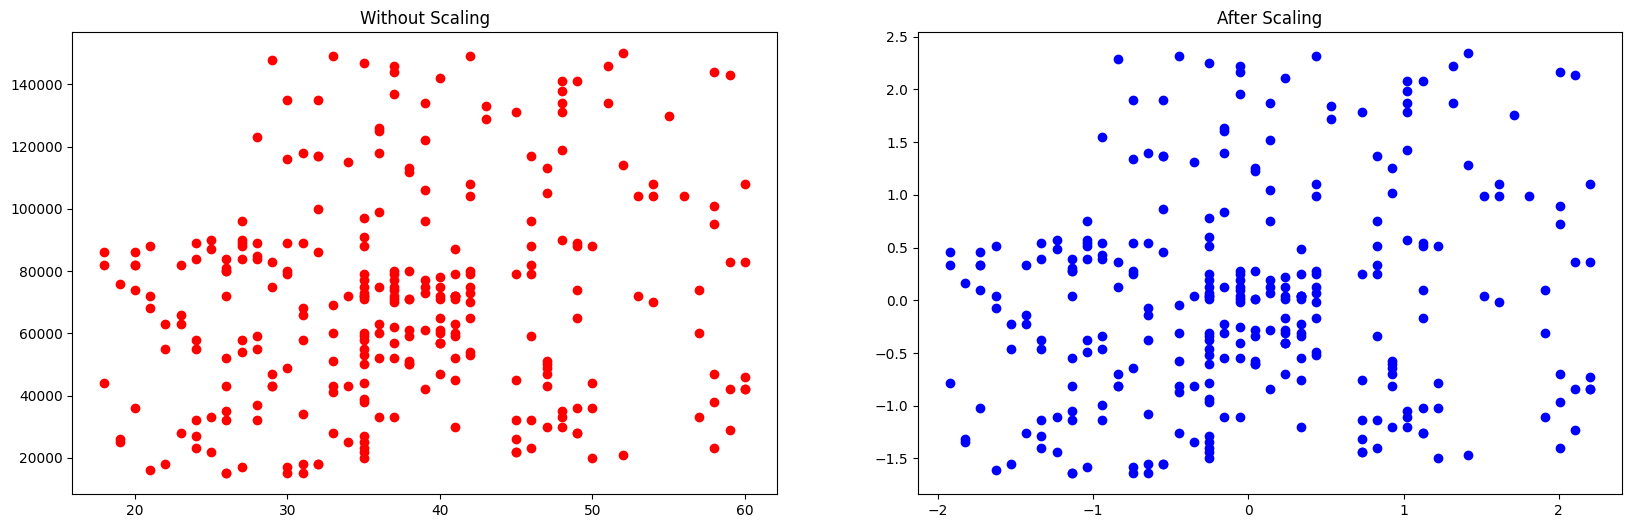

In [24]:
# Plot the Data
fig , ax = plt.subplots(1,2 , figsize=(20,6))
ax[0].scatter(X_train['Age'] , X_train['EstimatedSalary'],color='red')
ax[0].set_title("Without Scaling")
ax[1].scatter(X_train_scaled['Age'] , X_train_scaled['EstimatedSalary'],color='blue')
ax[1].set_title("After Scaling")
plt.show()

### We see that the points are at identically same distance b/w them but They have been compressed

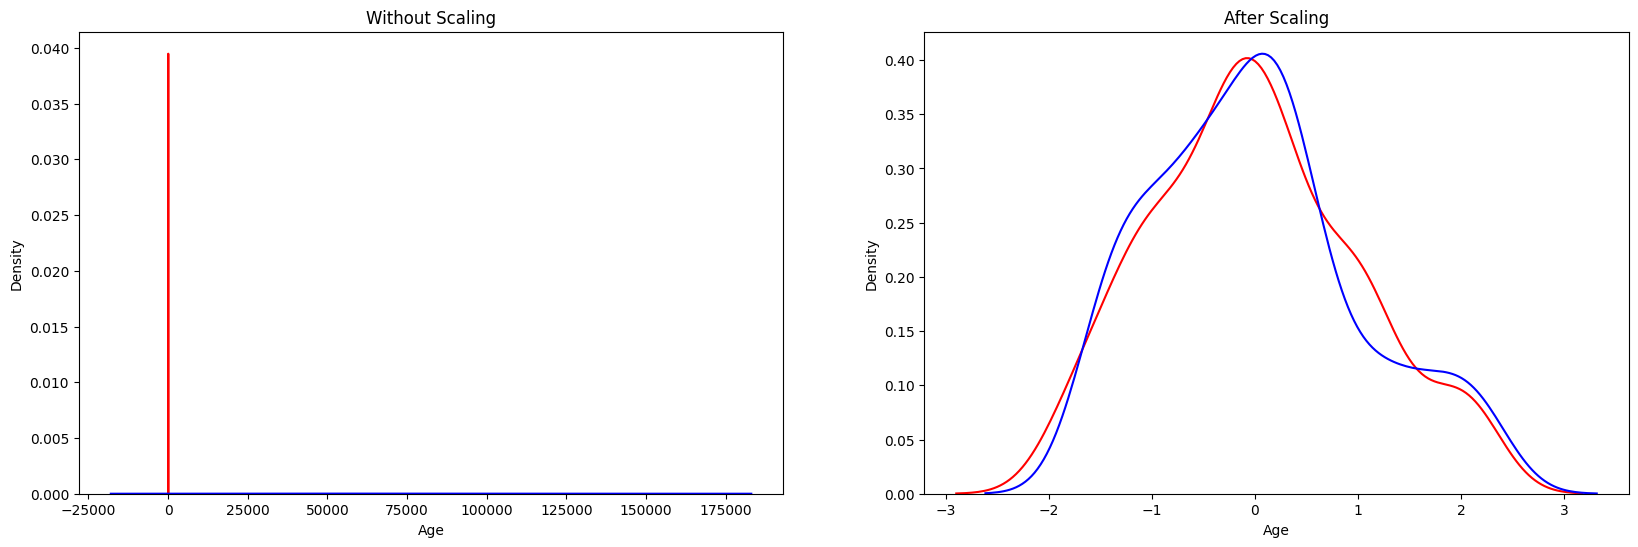

In [25]:
# Let us Plot the KDE PLOt
fig , ax = plt.subplots(1,2 , figsize=(20,6))
sns.kdeplot(data = X_train , x = 'Age',color='red' , ax=ax[0])
sns.kdeplot(data = X_train , x = 'EstimatedSalary',color='blue' , ax=ax[0])
sns.kdeplot(data = X_train_scaled , x = 'Age',color='red' , ax=ax[1])
sns.kdeplot(data = X_train_scaled , x = 'EstimatedSalary',color='blue' , ax=ax[1])
ax[0].set_title("Without Scaling")
ax[1].set_title("After Scaling")
plt.show()

### After Scaling we have Converted our Data into Standard Noraml distribution

### ***Accuracy Score After Scaling***

In [26]:
lr_scaled = LogisticRegression()
model_scaled = lr_scaled.fit(X_train_scaled , y_train)

y_pred_scaled  = model_scaled.predict(X_test_scaled)
print(f"Scaled data\nAccuracy Score -> {accuracy_score(y_test , y_pred_scaled)}")

Scaled data
Accuracy Score -> 0.85


In [27]:
from sklearn.metrics import classification_report
print(f"Classification Report\n ->{classification_report(y_test , y_pred_scaled)}")

Classification Report
 ->              precision    recall  f1-score   support

           0       0.82      0.97      0.89        73
           1       0.94      0.66      0.78        47

    accuracy                           0.85       120
   macro avg       0.88      0.82      0.83       120
weighted avg       0.86      0.85      0.84       120



In [28]:
print(f"Classification Report Without Scaled\n ->{classification_report(y_test , y_pred)}")

Classification Report Without Scaled
 ->              precision    recall  f1-score   support

           0       0.82      0.97      0.89        73
           1       0.94      0.66      0.78        47

    accuracy                           0.85       120
   macro avg       0.88      0.82      0.83       120
weighted avg       0.86      0.85      0.84       120



### ***There is No accuracy score changes but Scaling is really important, it gives reliable and stable results***